In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import  matplotlib
# matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
cats = pd.read_csv('DataSet/cat_breeds_dirty.csv', sep=';')
cats.head(30)

,Breed,Age_in_years,Age_in_months,Gender,Neutered_or_spayed,Body_length,Weight,Fur_colour_dominant,Fur_pattern,Eye_colour,Allowed_outdoor,Preferred_food,Owner_play_time_minutes,Sleep_time_hours,Country,Latitude,Longitude
0,Angora,0.250000,3.0,female,False,19.0,2.0,white,solid,blue,FALSE,wet,46.0,16.0,France,43.296482,5.369780
1,Angora,0.330000,4.0,male,False,19.0,2.5,white,solid,blue,FALSE,wet,48.0,16.0,France,43.611660,3.877710
2,Angora,0.500000,NaN,NaN,False,20.0,2.8,what does it mean dominant?,solid,green,I never allow my kitty outside!!!!!,wet,41.0,11.0,France,44.837789,-0.579180
3,Ankora,0.500000,NaN,NaN,False,21.0,3.0,white,dirty,blue,FALSE,wet,24.0,8.0,France,43.611660,3.877710
4,Angora,0.500000,NaN,NaN,NaN,21.0,3.0,red/cream,tabby,green,FALSE,wet,51.0,10.0,france,48.864716,2.349014
5,NaN,0.500000,6.0,female,False,21.0,3.0,white,solid,amber,FALSE,a lot of food,30.0,28.0,France,43.611660,3.877710
6,Angora,0.580000,NaN,NaN,NaN,22.0,3.0,white,solid,amber,FALSE,wet,47.0,9.0,France,47.218371,-1.553621
7,Angora,NaN,7.0,NaN,NaN,23.0,3.0,red/cream,NaN,cute,FALSE,wet,55.0,11.0,France,47.218371,-1.553621
8,Angora,NaN,7.0,female,NaN,25.0,3.0,black,NaN,blue,FALSE,wet,20.0,12.0,France,43.296482,5.369780
9,Angora,NaN,8.0,female,NaN,25.0,320.0,white,NaN,blue,FALSE,wet,33.0,17.0,France,44.837789,-0.579180


In [3]:
cats.info()

<class 'pandas.DataFrame'>
RangeIndex: 1103 entries, 0 to 1102
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Breed                    991 non-null    str    
 1   Age_in_years             1072 non-null   float64
 2   Age_in_months            1066 non-null   float64
 3   Gender                   1036 non-null   str    
 4   Neutered_or_spayed       1050 non-null   object 
 5   Body_length              1077 non-null   float64
 6   Weight                   1077 non-null   float64
 7   Fur_colour_dominant      1090 non-null   str    
 8   Fur_pattern              1055 non-null   str    
 9   Eye_colour               1064 non-null   str    
 10  Allowed_outdoor          1060 non-null   str    
 11  Preferred_food           1082 non-null   str    
 12  Owner_play_time_minutes  1082 non-null   float64
 13  Sleep_time_hours         1062 non-null   float64
 14  Country                  1028 non-n

## Garbage cleaning

In [4]:
def clean_text_data(df):
    for col in df.select_dtypes(['object', 'string']).columns:
        if df[col].dtype == 'str':
            df[col] = df[col].str.strip()

        if col in ['Country', 'Breed']:
            df[col] = df[col].str.title()

        if col in ['Allowed_outdoor']:
            df[col] = df[col].str.capitalize()

    return df

cats['Allowed_outdoor'] = cats['Allowed_outdoor'].astype('object')

cats = clean_text_data(cats)

cats

,Breed,Age_in_years,Age_in_months,Gender,Neutered_or_spayed,Body_length,Weight,Fur_colour_dominant,Fur_pattern,Eye_colour,Allowed_outdoor,Preferred_food,Owner_play_time_minutes,Sleep_time_hours,Country,Latitude,Longitude
0,Angora,0.250000,3.0,female,False,19.0,2.0,white,solid,blue,False,wet,46.0,16.0,France,43.296482,5.369780
1,Angora,0.330000,4.0,male,False,19.0,2.5,white,solid,blue,False,wet,48.0,16.0,France,43.611660,3.877710
2,Angora,0.500000,NaN,NaN,False,20.0,2.8,what does it mean dominant?,solid,green,I never allow my kitty outside!!!!!,wet,41.0,11.0,France,44.837789,-0.579180
3,Ankora,0.500000,NaN,NaN,False,21.0,3.0,white,dirty,blue,False,wet,24.0,8.0,France,43.611660,3.877710
4,Angora,0.500000,NaN,NaN,NaN,21.0,3.0,red/cream,tabby,green,False,wet,51.0,10.0,France,48.864716,2.349014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1098,Angora,4.170000,50.0,female,True,35.0,2.8,white,solid,amber,True,dry,28.0,14.0,Usa,45.523450,-122.676210
1099,Angora,-4.250000,-51.0,male,True,37.0,4.6,white,solid,amber,False,dry,36.0,14.0,France,45.763420,4.834277
1100,Angora,-4.333333,-52.0,female,True,34.0,4.3,white,solid,cute,False,wet,37.0,16.0,Usa,42.358430,-71.059770
1101,Angora,-4.333333,-52.0,female,True,35.0,3.8,black,solid,amber,False,wet,30.0,14.0,Usa,45.523450,-122.676210


In [5]:
good_breed = ['Angora', 'Maine Coon', 'Ragdoll']
trash_eye_color = ['cute', 'I dont know. Its pretty!']
trash_allowed_outdoor = ['I never allow my kitty outside!!!!!', "I dont allow her outside. i'm a responsible owner"]
trash_country_words = ['La France!!!!', 'Vive La France!', 'My Country', 'Where I Live', 'With Me']

for col in cats.select_dtypes(['float']).columns:
    if col not in ['Latitude', 'Longitude']:
        cats[col] = cats[col].map(lambda x: np.nan if x < 0 else x)

cats.loc[~cats['Breed'].isin(good_breed), 'Breed'] = np.nan
cats.loc[cats['Fur_colour_dominant'].isin(['what does it mean dominant?']), 'Fur_colour_dominant'] = np.nan
cats.loc[cats['Fur_pattern'].isin(['dirty']), 'Fur_pattern'] = np.nan
cats.loc[cats['Eye_colour'].isin(trash_eye_color), 'Eye_colour'] = np.nan
cats.loc[cats['Allowed_outdoor'].isin(trash_allowed_outdoor), 'Allowed_outdoor'] = np.nan
cats.loc[cats['Preferred_food'].isin(['a lot of food']), 'Preferred_food'] = np.nan
cats.loc[cats['Country'].isin(trash_country_words), 'Country'] = np.nan
cats.loc[cats['Fur_colour_dominant'] == 'brown/chocolate', 'Fur_colour_dominant'] = 'brown'
cats.loc[cats['Fur_colour_dominant'] == 'red/cream', 'Fur_colour_dominant'] = 'cream'
cats.loc[cats['Fur_pattern'] == 'colorpoint', 'Fur_pattern'] = 'cpoint'




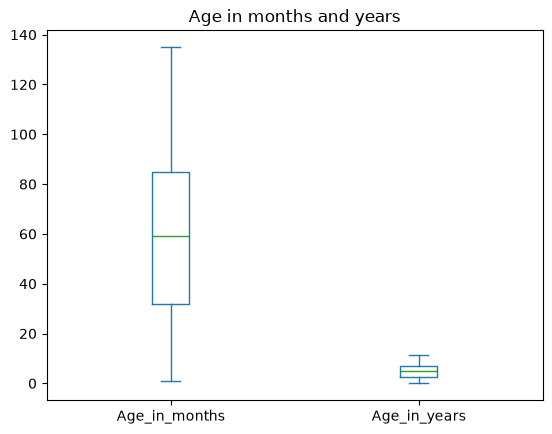

In [6]:
cats[['Age_in_months', 'Age_in_years']].plot.box(title='Age in months and years')
plt.show()

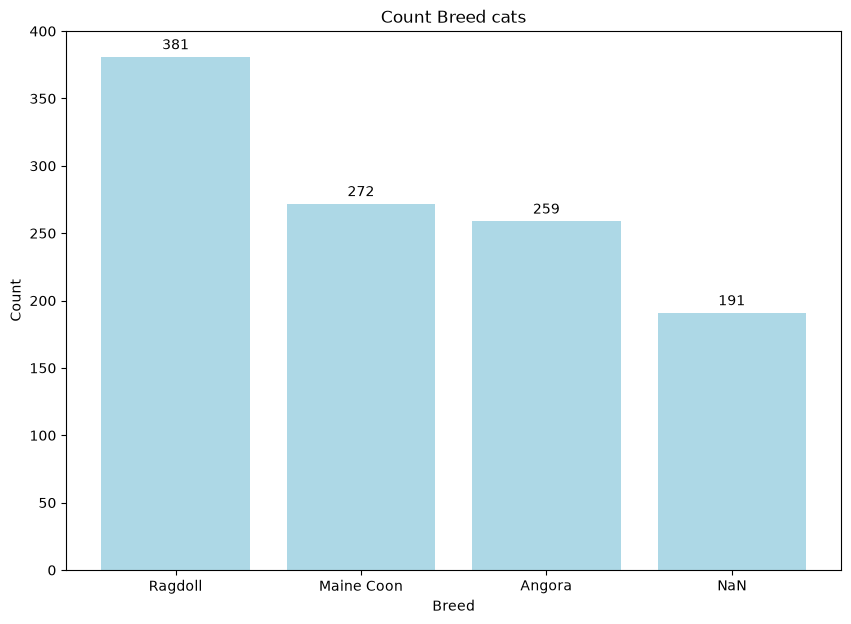

In [7]:
counts = cats['Breed'].value_counts(dropna=False)
counts.index = counts.index.fillna('NaN')
fig, ax = plt.subplots(nrows=1,ncols=1, figsize=(10,7))
bars = ax.bar(counts.index.astype(str), counts.values, color='lightblue')
ax.bar_label(bars, padding=3)
ax.set_title('Count Breed cats')
ax.set_xlabel('Breed')
ax.set_ylabel('Count')




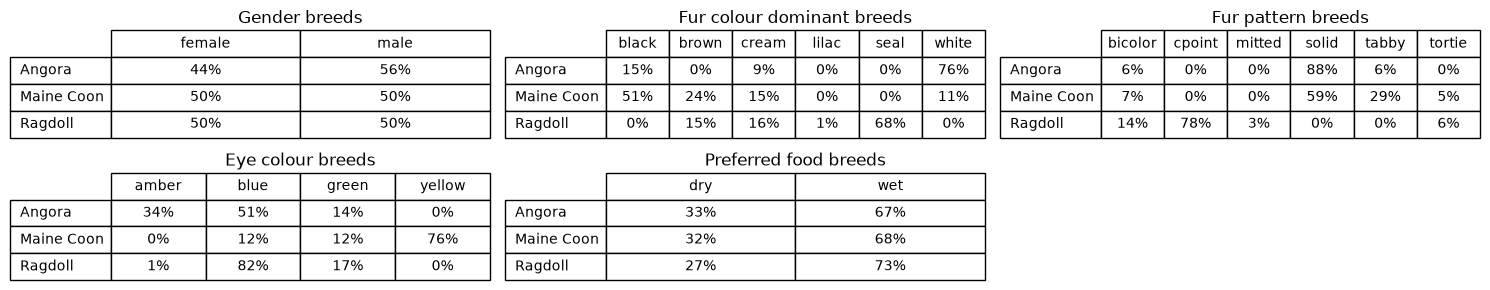

In [8]:
categt = cats.select_dtypes(include='str').drop(columns=['Country', 'Breed'], errors='ignore')
catc = categt.columns

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 3))
axr = ax.ravel()


for i, axi in enumerate(axr[:5]):
    axi.axis('off')
    ct = pd.crosstab(cats['Breed'], cats[catc[i]], normalize='index') * 100
    table = axi.table(
        cellText=[[f'{val:.0f}%' for val in row] for row in ct.values],
        rowLabels= ct.index,
        colLabels=ct.columns,
        cellLoc='center',
        loc='center',
    )
    table.auto_set_font_size(False)
    table.scale(1, 1.6)
    axi.set_title(f'{catc[i].replace('_', ' ')} breeds')

fig.delaxes(axr[5])
fig.tight_layout()



## Filling in the average weight and length, as well as calculating the age in years and months

In [9]:
for col in cats.columns:
    if col in ['Weight', 'Body_length']:
        filling_group = cats.groupby(['Breed', 'Gender'])[col].transform('mean')
        cats[col] = cats[col].fillna(filling_group)

cats.loc[cats['Age_in_years'].isnull(), 'Age_in_years'] = cats['Age_in_months'] / 12
cats.loc[cats['Age_in_months'].isnull(), 'Age_in_months'] = cats['Age_in_years'] * 12
cats.info()

<class 'pandas.DataFrame'>
RangeIndex: 1103 entries, 0 to 1102
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Breed                    912 non-null    str    
 1   Age_in_years             1055 non-null   float64
 2   Age_in_months            1055 non-null   float64
 3   Gender                   1036 non-null   str    
 4   Neutered_or_spayed       1050 non-null   object 
 5   Body_length              1090 non-null   float64
 6   Weight                   1090 non-null   float64
 7   Fur_colour_dominant      1089 non-null   str    
 8   Fur_pattern              1046 non-null   str    
 9   Eye_colour               1056 non-null   str    
 10  Allowed_outdoor          1058 non-null   object 
 11  Preferred_food           1081 non-null   str    
 12  Owner_play_time_minutes  1082 non-null   float64
 13  Sleep_time_hours         1062 non-null   float64
 14  Country                  1022 non-n

## Grouping data by gender and breed based on their average length and weight, working with centroids, detecting anomalies using Euclidean distance, and determining unknown gender and breed with subsequent data imputation into a table

In [10]:
def find_closest_gender_with_nuance(row, centers, threshold=0.5):
    if pd.notna(row['Gender']):
        return row['Gender']

    if pd.isna(row['Weight']) and pd.isna(row['Body_length']):
        return np.nan

    if pd.notna(row['Breed']):
        same_breed_centers = centers[centers['Breed'] == row['Breed']]
    else:
        same_breed_centers = centers

    if len(same_breed_centers) < 2:
        return np.nan

    male_center = same_breed_centers[same_breed_centers['Gender'] == 'male'].iloc[0]
    female_center = same_breed_centers[same_breed_centers['Gender'] == 'female'].iloc[0]

    breed_dimorphism = np.sqrt(
        (male_center['Weight'] - female_center['Weight'])**2 +
        (male_center['Body_length'] - female_center['Body_length'])**2
    )

    if breed_dimorphism < threshold:
        return np.nan

    distances = np.sqrt(
        (same_breed_centers['Weight'] - row['Weight']).fillna(0)**2 +
        (same_breed_centers['Body_length'] - row['Body_length']).fillna(0)**2
    )

    closest_index = distances.idxmin()
    return same_breed_centers.loc[closest_index, 'Gender']

breed_centers = cats.groupby(['Gender', 'Breed'])[['Weight', 'Body_length']].mean().reset_index()
cats['Gender'] = cats.apply(lambda row: find_closest_gender_with_nuance(row, breed_centers) , axis=1)

In [11]:
def find_closest_breed(row, centers):
    if pd.notna(row['Breed']):
        return row['Breed']
    if pd.isna(row['Weight']) and pd.isna(row['Body_length']):
        return np.nan
    if pd.notna(row['Gender']):
        same_gender_centers = centers[centers['Gender'] == row['Gender']]
    else:
        same_gender_centers = centers

    if same_gender_centers.empty:
        return np.nan
    distance = np.sqrt(
        (same_gender_centers['Weight'] - row['Weight']).fillna(0) ** 2 +
        (same_gender_centers['Body_length'] - row['Body_length']) ** 2
    )
    closest_idx = distance.idxmin()
    return same_gender_centers.loc[closest_idx, 'Breed']


cats['Breed'] = cats.apply(lambda row: find_closest_breed(row, breed_centers), axis=1)
cats.info()


<class 'pandas.DataFrame'>
RangeIndex: 1103 entries, 0 to 1102
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Breed                    1090 non-null   str    
 1   Age_in_years             1055 non-null   float64
 2   Age_in_months            1055 non-null   float64
 3   Gender                   1090 non-null   str    
 4   Neutered_or_spayed       1050 non-null   object 
 5   Body_length              1090 non-null   float64
 6   Weight                   1090 non-null   float64
 7   Fur_colour_dominant      1089 non-null   str    
 8   Fur_pattern              1046 non-null   str    
 9   Eye_colour               1056 non-null   str    
 10  Allowed_outdoor          1058 non-null   object 
 11  Preferred_food           1081 non-null   str    
 12  Owner_play_time_minutes  1082 non-null   float64
 13  Sleep_time_hours         1062 non-null   float64
 14  Country                  1022 non-n

## Filling in the coordinates by determining the most popular coordinates in the country and then calculating the average longitude and latitude in those coordinates, and if there is no data, taking the average for the country. Filling in the remaining values

In [12]:
coords_country = cats.groupby(['Latitude', 'Longitude'])['Country'].transform(lambda x: x.mode().iloc[0] if not x.empty else np.nan)
cats['Country'] = cats['Country'].fillna(coords_country)
cats.info()

<class 'pandas.DataFrame'>
RangeIndex: 1103 entries, 0 to 1102
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Breed                    1090 non-null   str    
 1   Age_in_years             1055 non-null   float64
 2   Age_in_months            1055 non-null   float64
 3   Gender                   1090 non-null   str    
 4   Neutered_or_spayed       1050 non-null   object 
 5   Body_length              1090 non-null   float64
 6   Weight                   1090 non-null   float64
 7   Fur_colour_dominant      1089 non-null   str    
 8   Fur_pattern              1046 non-null   str    
 9   Eye_colour               1056 non-null   str    
 10  Allowed_outdoor          1058 non-null   object 
 11  Preferred_food           1081 non-null   str    
 12  Owner_play_time_minutes  1082 non-null   float64
 13  Sleep_time_hours         1062 non-null   float64
 14  Country                  1060 non-n

In [13]:
for col in cats.columns:
    if col in ['Weight', 'Body_length', 'Owner_play_time_minutes', 'Sleep_time_hours', 'Age_in_years']:
        filling_group = cats.groupby(['Breed', 'Gender'])[col].transform('mean')
        cats[col] = cats[col].fillna(filling_group)

    if col in ['Preferred_food', 'Eye_colour', 'Allowed_outdoor', 'Country', ' Fur_pattern',
               'Neutered_or_spayed', 'Fur_colour_dominant', 'Fur_pattern']:
        filling_group = cats.groupby(['Breed', 'Gender'])[col].transform(
    lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
        cats[col] = cats[col].fillna(filling_group)

cats['Age_in_months'] = cats['Age_in_years'] / 12
cats.info()

<class 'pandas.DataFrame'>
RangeIndex: 1103 entries, 0 to 1102
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Breed                    1090 non-null   str    
 1   Age_in_years             1102 non-null   float64
 2   Age_in_months            1102 non-null   float64
 3   Gender                   1090 non-null   str    
 4   Neutered_or_spayed       1090 non-null   object 
 5   Body_length              1090 non-null   float64
 6   Weight                   1090 non-null   float64
 7   Fur_colour_dominant      1090 non-null   str    
 8   Fur_pattern              1090 non-null   str    
 9   Eye_colour               1097 non-null   str    
 10  Allowed_outdoor          1097 non-null   object 
 11  Preferred_food           1101 non-null   str    
 12  Owner_play_time_minutes  1102 non-null   float64
 13  Sleep_time_hours         1103 non-null   float64
 14  Country                  1103 non-n

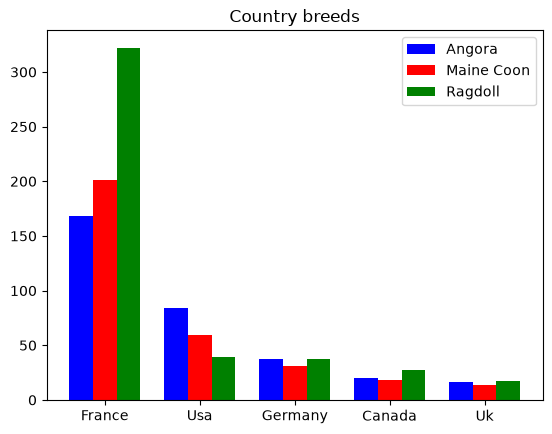

In [14]:
fig, axes = plt.subplots(nrows=1, ncols=1)
catscountry = cats.groupby(['Breed'])['Country'].value_counts()
print(catscountry)
countrys = cats['Country'].unique().astype(str)
x = np.arange(len(countrys))
bar1 = axes.bar(x - 0.25, catscountry.values[:5], 0.25,  color='blue', label='Angora')
bar2 = axes.bar(x, catscountry.values[5:10], 0.25,  color='red', label='Maine Coon')
bar3 = axes.bar(x + 0.25, catscountry.values[10:15], 0.25, color='green', label='Ragdoll')
axes.set_xticklabels(countrys)
axes.set_xticks(x)
axes.set_title('Country breeds')
axes.legend()




In [15]:
cats['lat_grid'] = cats['Latitude'].round(1)
cats['lon_grid'] = cats['Longitude'].round(1)


def get_main_country_center(group):
    mode_lat = group['lat_grid'].mode()
    mode_lon = group['lon_grid'].mode()

    if not mode_lat.empty and not mode_lon.empty:
        main_cluster = group[(group['lat_grid'] == mode_lat.iloc[0]) & (group['lon_grid'] == mode_lon.iloc[0])]
        return pd.Series([main_cluster['Latitude'].mean(), main_cluster['Longitude'].mean()], index=['Default_Lat', 'Default_Lon'])
    else:
        return pd.Series([group['Latitude'].mean(), group['Longitude'].mean()], index=['Default_Lat', 'Default_Lon'])

country_centers = cats.dropna(subset=['Latitude', 'Longitude']).groupby('Country').apply(get_main_country_center).reset_index()

cats = cats.merge(country_centers, on='Country', how='left')

cats['Latitude'] = cats['Latitude'].fillna(cats['Default_Lat'])
cats['Longitude'] = cats['Longitude'].fillna(cats['Default_Lon'])

cats = cats.drop(columns=['lat_grid', 'lon_grid', 'Default_Lat', 'Default_Lon'])
cats.dropna(subset=['Latitude', 'Longitude']).groupby('Country')


## deleting the remaining empty values


In [16]:
cats = cats.dropna(subset=['Breed', 'Gender', 'Weight'], how='all')
cats.info()

<class 'pandas.DataFrame'>
Index: 1090 entries, 0 to 1102
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Breed                    1090 non-null   str    
 1   Age_in_years             1090 non-null   float64
 2   Age_in_months            1090 non-null   float64
 3   Gender                   1090 non-null   str    
 4   Neutered_or_spayed       1090 non-null   object 
 5   Body_length              1090 non-null   float64
 6   Weight                   1090 non-null   float64
 7   Fur_colour_dominant      1090 non-null   str    
 8   Fur_pattern              1090 non-null   str    
 9   Eye_colour               1090 non-null   str    
 10  Allowed_outdoor          1090 non-null   object 
 11  Preferred_food           1090 non-null   str    
 12  Owner_play_time_minutes  1090 non-null   float64
 13  Sleep_time_hours         1090 non-null   float64
 14  Country                  1090 non-null  

## Final study

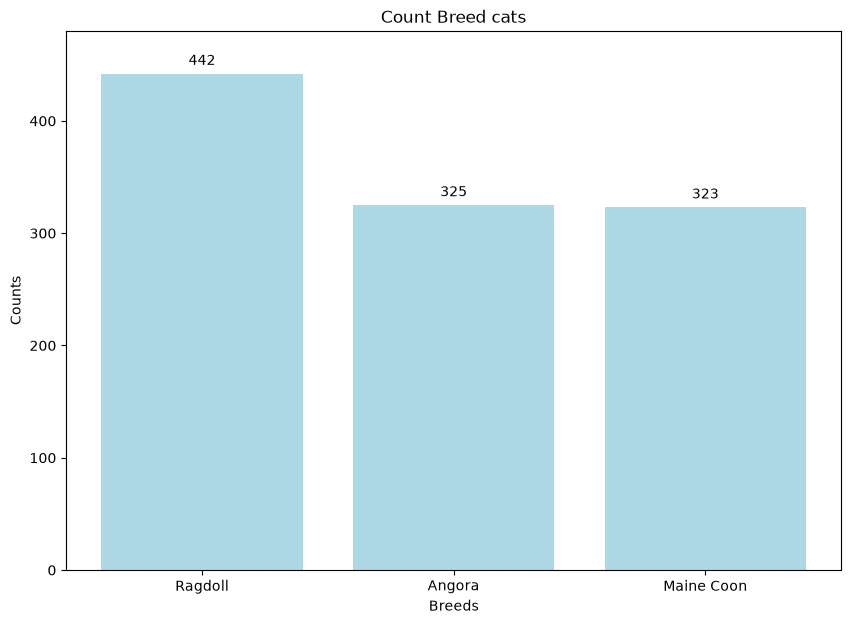

In [17]:
counts = cats['Breed'].value_counts(dropna=False)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 7))
bar = ax.bar(counts.index.astype(str), counts.values, color='lightblue')
ax.bar_label(bar, padding=4)
ax.set_title('Count Breed cats')
ax.set_ylim(0, 480)
ax.set_xlabel('Breeds')
ax.set_ylabel('Counts')

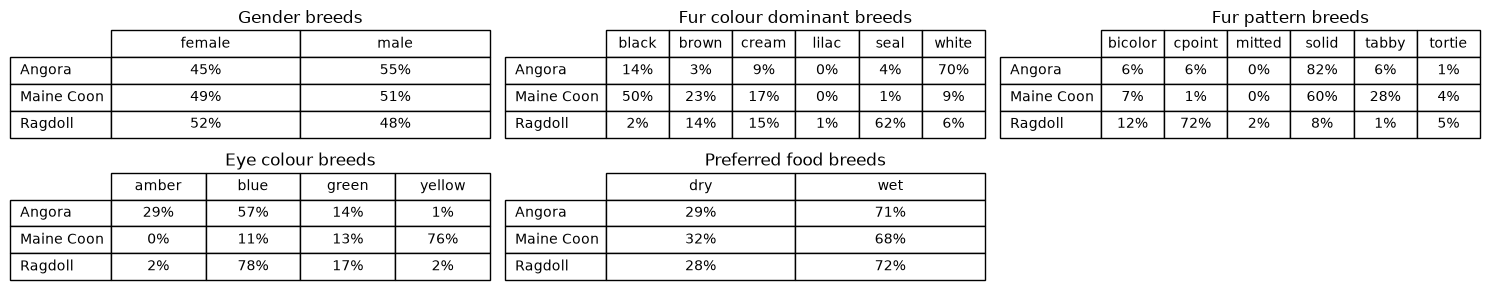

In [18]:
categt = cats.select_dtypes(include='str').drop(columns=['Country', 'Breed'], errors='ignore')
catc = categt.columns

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 3))
axr = ax.ravel()

for i, axi in enumerate(axr[:5]):
    axi.axis('off')
    ct = pd.crosstab(cats['Breed'], cats[catc[i]], normalize='index') * 100
    table = axi.table(
        cellText=[[f'{val:.0f}%' for val in row] for row in ct.values],
        rowLabels= ct.index,
        colLabels=ct.columns,
        cellLoc='center',
        loc='center',
    )
    table.auto_set_font_size(False)
    table.scale(1, 1.6)
    axi.set_title(f'{catc[i].replace('_', ' ')} breeds')

fig.delaxes(axr[5])
fig.tight_layout()


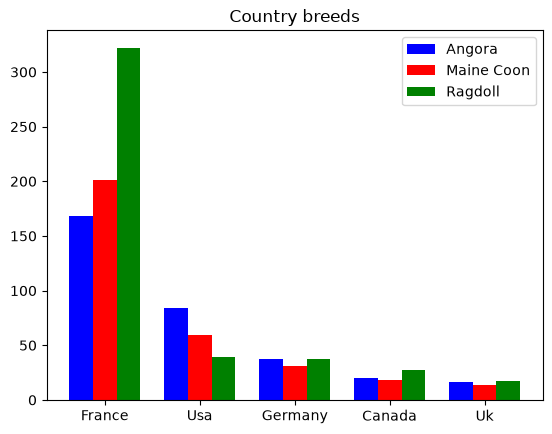

In [19]:
fig, axes = plt.subplots(nrows=1, ncols=1)
catscountry = cats.groupby(['Breed'])['Country'].value_counts()
countrys = cats['Country'].unique().astype(str)
x = np.arange(len(countrys))
bar1 = axes.bar(x - 0.25, catscountry.values[:5], 0.25,  color='blue', label='Angora')
bar2 = axes.bar(x, catscountry.values[5:10], 0.25,  color='red', label='Maine Coon')
bar3 = axes.bar(x + 0.25, catscountry.values[10:15], 0.25, color='green', label='Ragdoll')
axes.set_xticklabels(countrys)
axes.set_xticks(x)
axes.set_title('Country breeds')
axes.legend()
